### EXPLANATORY DATA ANALYSIS

In [6]:
#Import necessary libraries
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product


In [7]:
# Data Loading
Data_dir_path = os.path.join(os.path.dirname(os.getcwd()), "data", "raw")
file_path = os.path.join(Data_dir_path, "ANN data_316.xlsx")
print(file_path)
# Read  as a dataframe
df = pd.read_excel(file_path)
df.head(10)

/home/mlops-localhost/PycharmProjects/aisi304-flow-stress-optimizer/data/raw/ANN data_316.xlsx


,1/T,ln strain rate,Strain,σ/σmax,ε͘΄
0,0.000818,-2.302585,0.1,0.375990,0.100000
1,0.000786,-2.302585,0.1,0.309844,0.100000
2,0.000756,-2.302585,0.1,0.172481,0.100000
3,0.000818,0.000000,0.1,0.533258,0.467632
4,0.000786,0.000000,0.1,0.455666,0.467632
5,0.000756,0.000000,0.1,0.295477,0.467632
6,0.000818,2.302585,0.1,0.635860,0.835263
7,0.000786,2.302585,0.1,0.552193,0.835263
8,0.000756,2.302585,0.1,0.406252,0.835263
9,0.000818,2.708050,0.1,0.668228,0.900000


In [8]:
df.shape

(84, 5)

- The original data has 84 rows of data and 5 columns of data

In [9]:
df.dtypes

1/T               float64
ln strain rate    float64
Strain            float64
σ/σmax            float64
ε͘΄               float64
dtype: object

- All the data types are numbers (float)

In [10]:
# Check for null values
df.isnull().sum()

1/T               0
ln strain rate    0
Strain            0
σ/σmax            0
ε͘΄               0
dtype: int64

- There are no null values in the dataset

In [11]:
# Check for duplicates
duplicates = df[df.duplicated()]
print(duplicates.sum())

1/T               0.0
ln strain rate    0.0
Strain            0.0
σ/σmax            0.0
ε͘΄               0.0
dtype: float64


- There are no duplicate values in the dataset

In [12]:
# Get the dataset description
df.describe()

,1/T,ln strain rate,Strain,σ/σmax,ε͘΄
count,84.000000,84.000000,84.000000,84.000000,84.000000
mean,0.000786,0.677013,0.400000,0.651643,0.575724
std,0.000025,2.018537,0.201201,0.201241,0.322280
min,0.000756,-2.302585,0.100000,0.172481,0.100000
25%,0.000756,-0.575646,0.200000,0.501783,0.375724
50%,0.000786,1.151293,0.400000,0.665536,0.651447
75%,0.000818,2.403951,0.600000,0.812758,0.851447
max,0.000818,2.708050,0.700000,1.000000,0.900000


- The dataset has 84 rows and 5 columns.
- The mean, standard deviation, minimum, and maximum values for each column are provided in the description.
- The '1/T' column has a mean of approximately 0.0033, while the 'ln strain rate' column has a mean of approximately -17. The 'Strain' column has a mean of approximately 0.0002, and the 'Flow stress' column has a mean of approximately 200 MPa.

In [13]:
# Check for unique values per column.
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"Unique values in column '{column}: {unique_values}")

Unique values in column '1/T: 3
Unique values in column 'ln strain rate: 4
Unique values in column 'Strain: 7
Unique values in column 'σ/σmax: 84
Unique values in column 'ε͘΄: 4


In [14]:
#Check whether the data is a 4 by 4 complete grid
# Step 1: Calculate the expected rows and column for a 4 by 4 grid
expected = df['1/T'].nunique() * df['ln strain rate'].nunique() * df['Strain'].nunique()
print(f"Expected Rows: {expected}")
print(f"Actual rows: {len(df)}")

# Step 2: Check for missing combinations
all_combinations = list(product(df['1/T'].unique(), df['ln strain rate'].unique(), df['Strain'].unique()))
actual_combinations = set(zip(df['1/T'], df['ln strain rate'], df['Strain']))
missing_combinations = [comb for comb in all_combinations if comb not in actual_combinations]
print(f"Missing combinations:", len(missing_combinations))


Expected Rows: 84
Actual rows: 84
Missing combinations: 0


- Our dataset has 84 rows, which is more than the expected 64 rows for a complete 4 by 4 grid. This indicates that there are duplicate combinations of '1/T', 'ln strain rate', and 'Strain' in the dataset. Additionally, there are no missing combinations, meaning all possible combinations of the three variables are present in the dataset.

## VISUALIZATION OF DATA PATTERNS

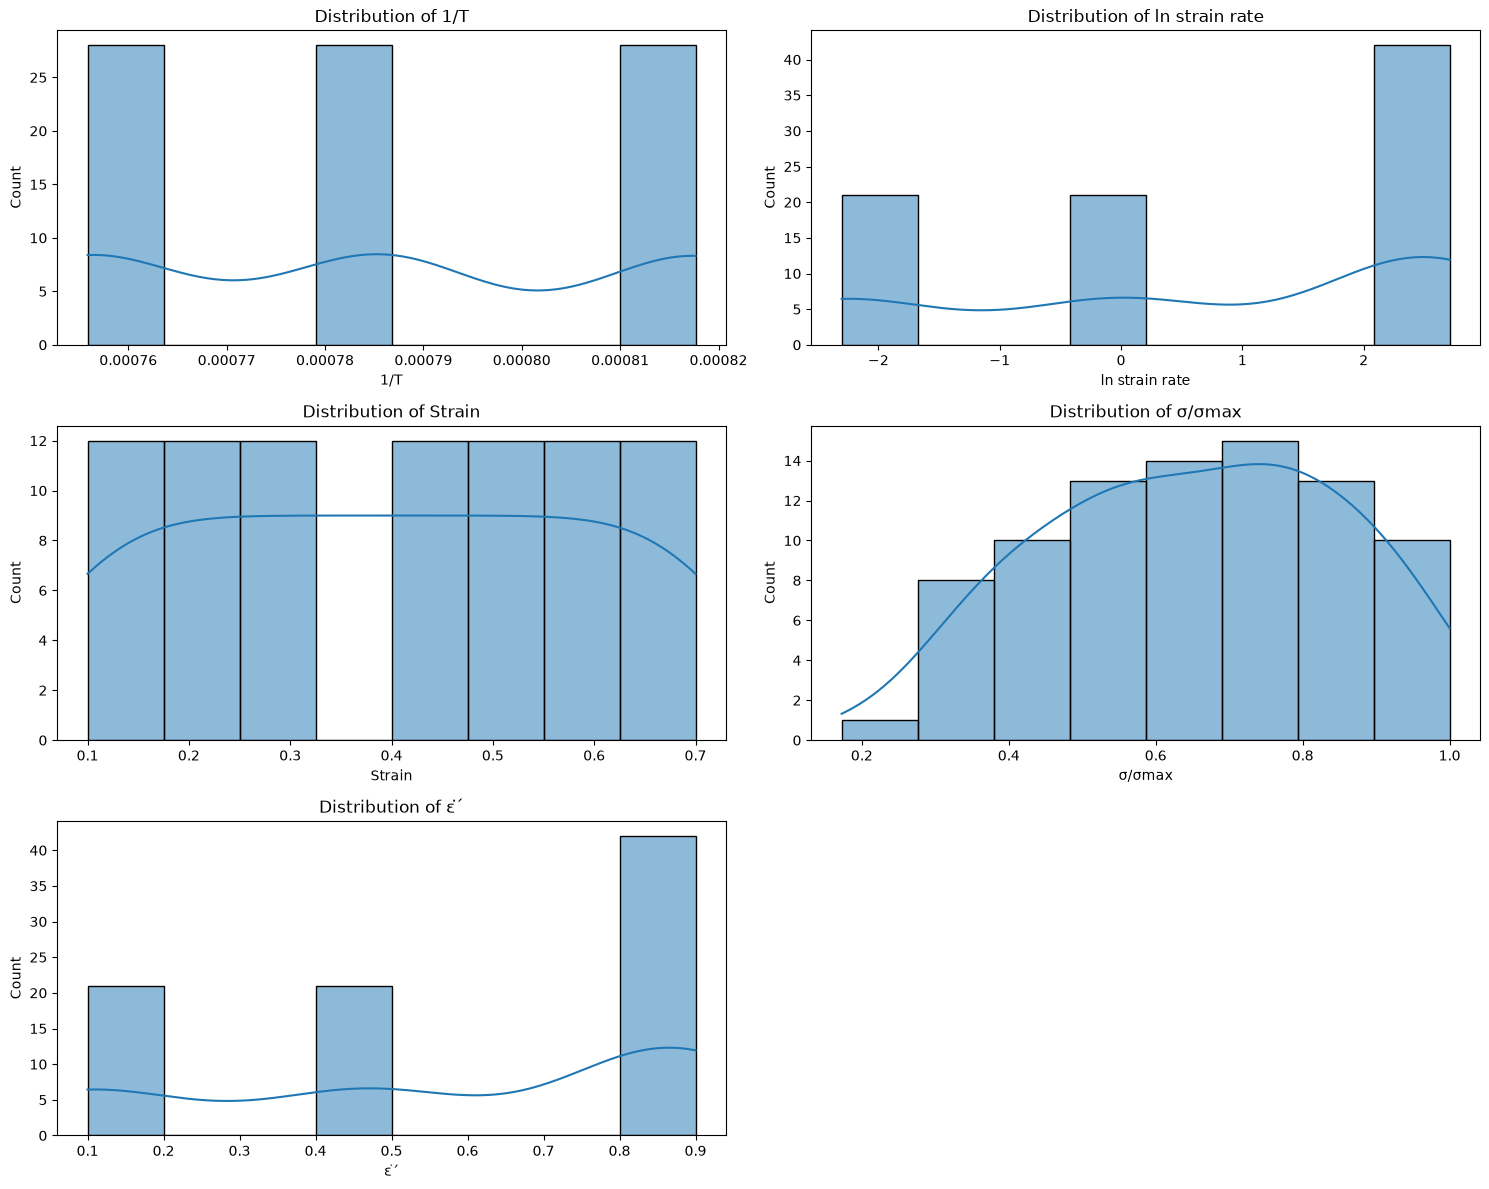

In [15]:
# Distribution plots - to understand the distribution of each variable
plt.figure(figsize=(15,12))
for i, column in enumerate(df.columns):
    plt.subplot(3,2, i + 1)
    sns.histplot(df[column], kde = True)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

### DISTRIBUTION PLOTS
1. 1/T (Temperature): Three discrete bars of roughly equal height (~27 each). This confirms 3 distinct temperature levels, evenly represented. Clean, no imbalance.

2. ln strain rate: Four discrete bars but unequally represented, the highest strain rate (≈2.3) has ~40 counts while the lowest (≈-2.3) has ~20. This means higher strain rates were tested at more strain levels, or appear more in the dataset. Worth keeping in mind during training that the model will see more of one strain rate than others.

3. Strain: The most uniform of all inputs. Every strain level from 0.1 to 0.7 appears with roughly equal frequency (~12 each). This is ideal, no strain value dominates training.

4. σ/σmax (Target): It's right-skewed, concentrated between 0.5 and 0.9, with very few values near 0.2 or 1.0. This means that the model will have less exposure to extreme flow stress values, both very low and near-maximum. That's a known risk area for prediction accuracy, the model will also benefit more from log transforming the target to reduce skewness and improve performance.

5. ε' (raw strain rate): Mirror of ln strain rate as expected, three clusters at 0.1, 0.47, and 0.9. Confirms it carries no new information beyond what ln strain rate already captures. Drop it as an input feature.

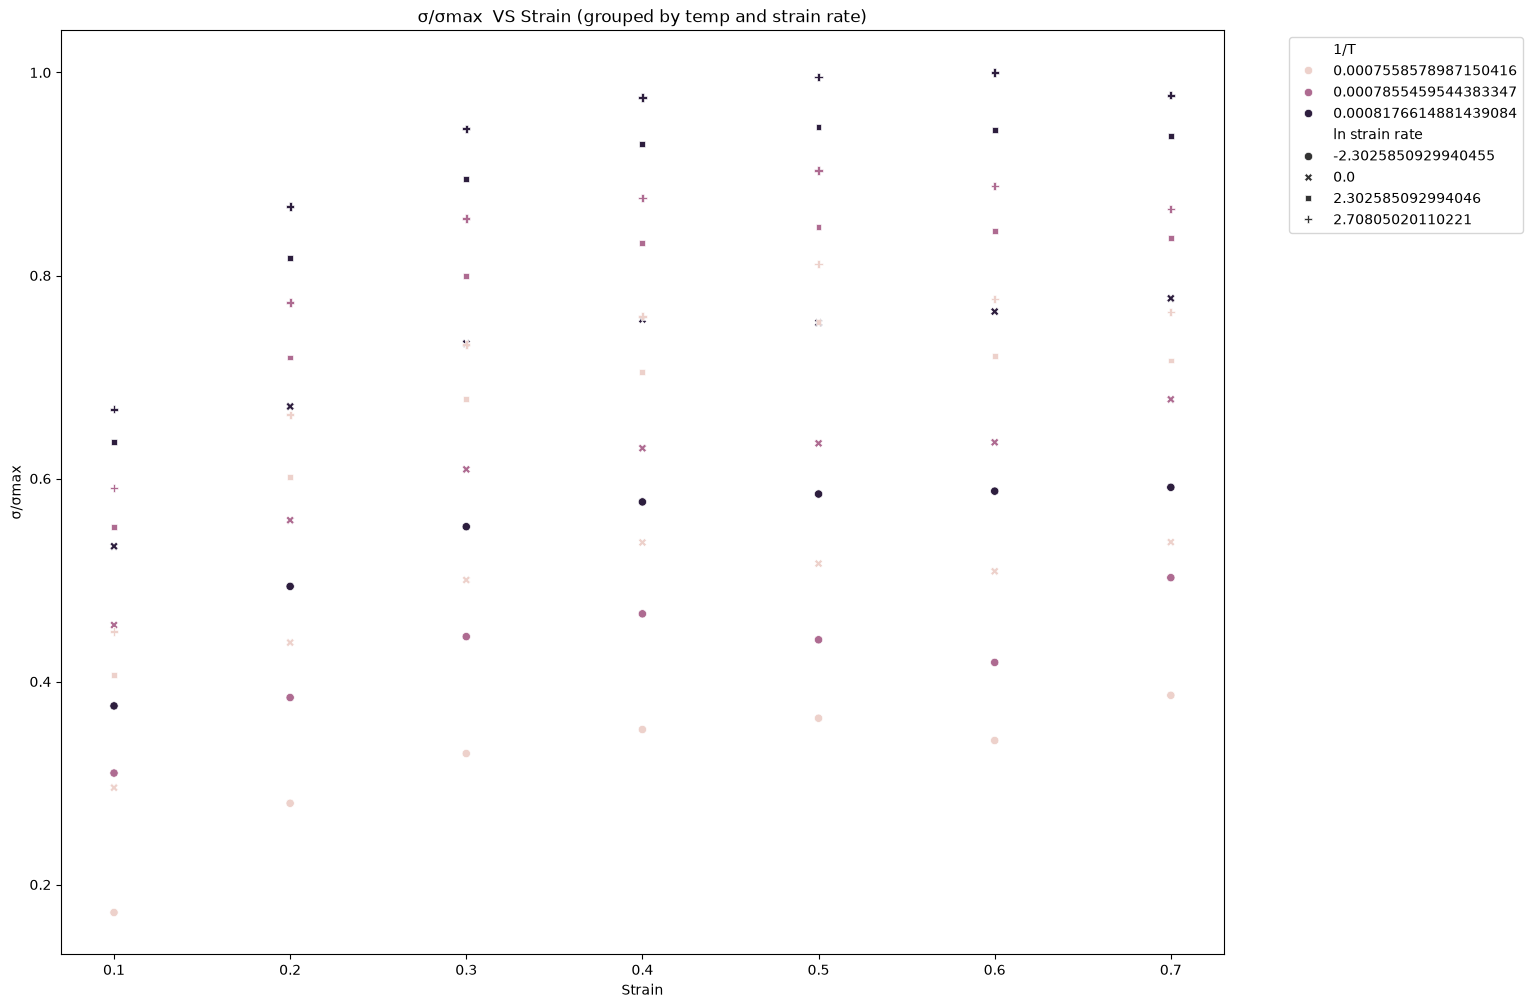

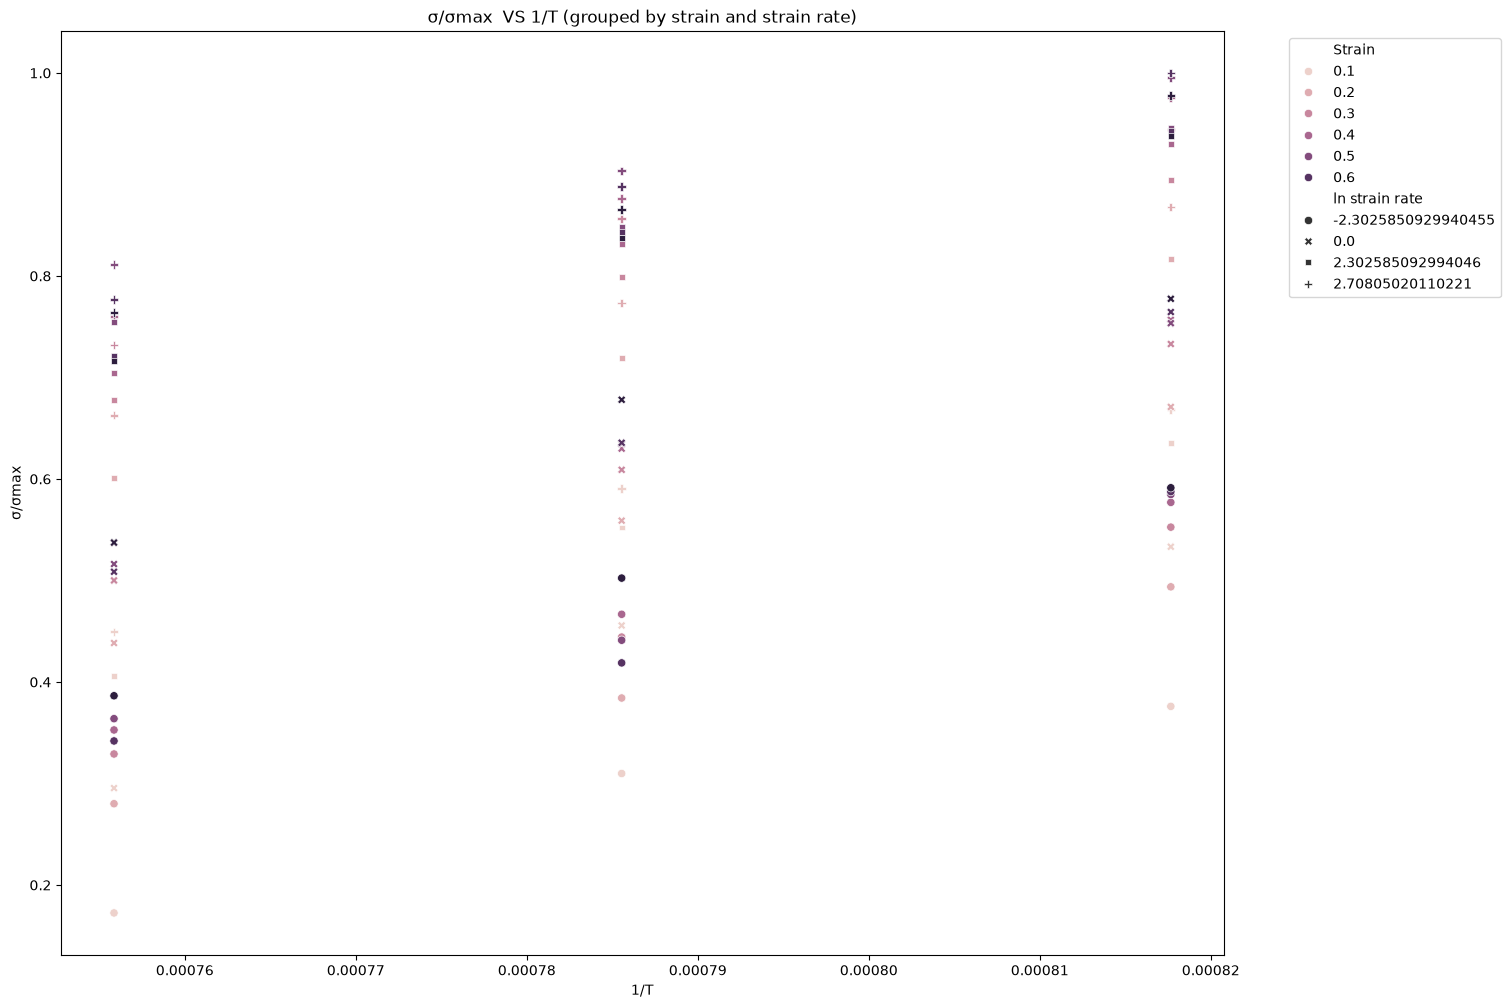

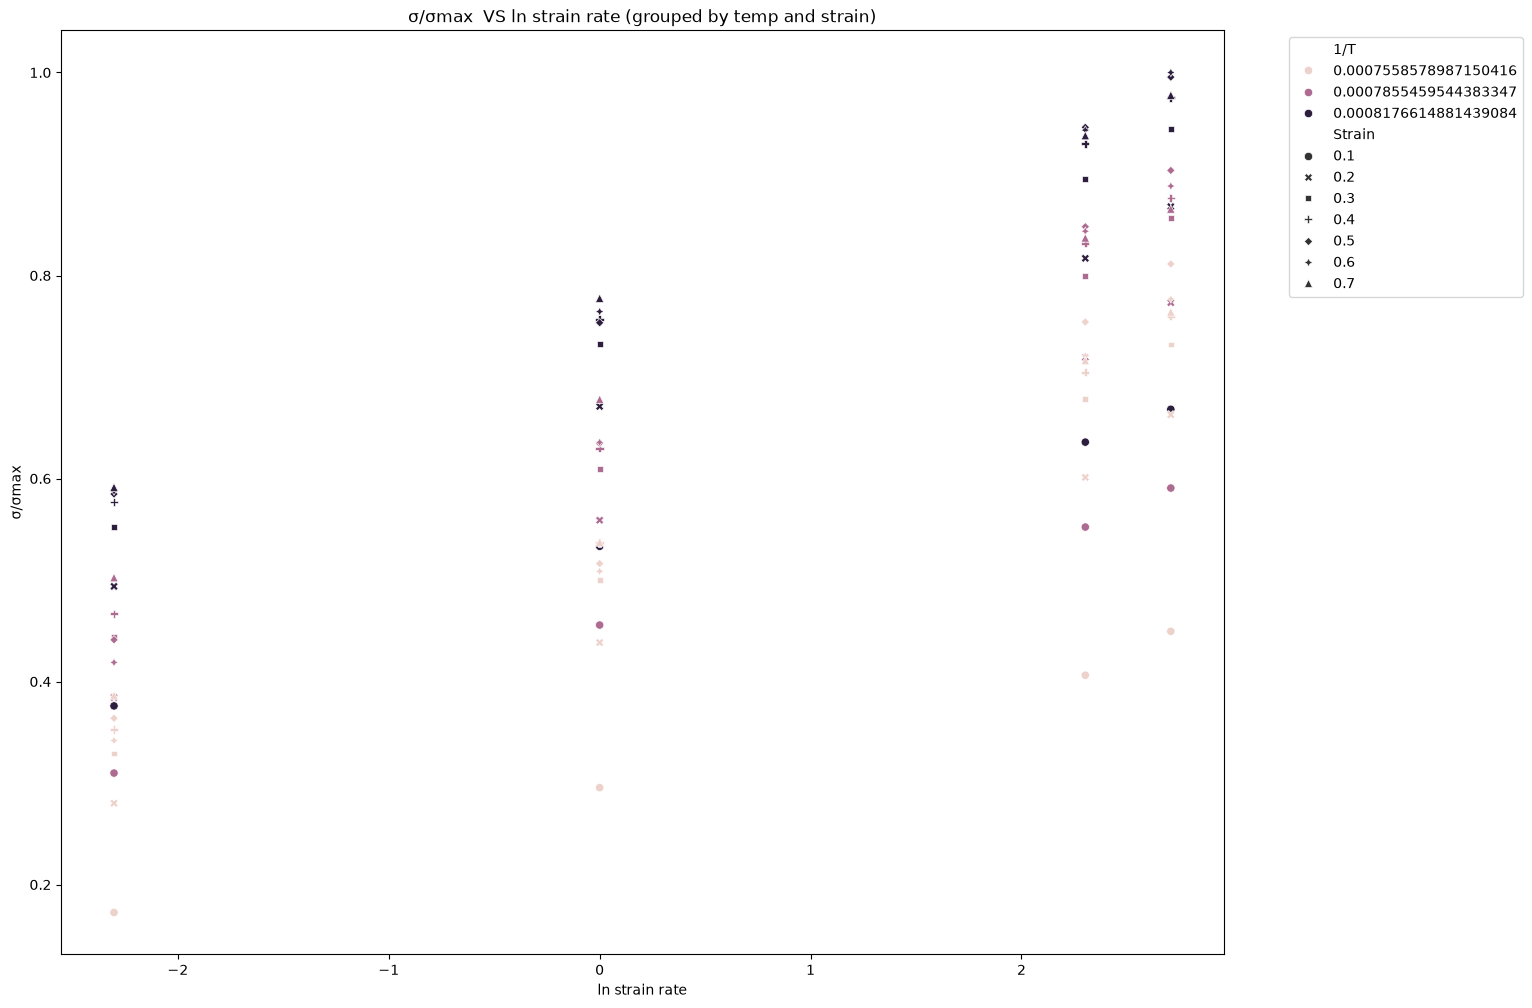

In [16]:
# Relationship plots - to understand the relationships between variables
# Step 1: σ/σmax  VS Strain ( grouped by temp and strain rate)
plt.figure(figsize=(15,12))
sns.scatterplot(data=df, x='Strain', y = 'σ/σmax', hue = '1/T', style = 'ln strain rate')
plt.title('σ/σmax  VS Strain (grouped by temp and strain rate)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# Step 2: σ/σmax vs 1/T (grouped by strain and strain rate)
plt.figure(figsize=(15,12))
sns.scatterplot(data = df, x='1/T', y = 'σ/σmax', hue = 'Strain', style = 'ln strain rate')
plt.title('σ/σmax  VS 1/T (grouped by strain and strain rate)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()


# Step 3: σ/σmax vs ln strain rate (grouped by temp and strain)
plt.figure(figsize=(15,12))
sns.scatterplot(data = df, x='ln strain rate', y = 'σ/σmax', hue = '1/T', style = 'Strain')
plt.title('σ/σmax  VS ln strain rate (grouped by temp and strain)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()


## Exploratory Plot Notes

### Plot 1: Normalized Flow Stress (σ/σmax) vs Strain

This plot shows the clearest relationship in the dataset. As strain increases from **0.1 to 0.7**, the normalized flow stress (**σ/σmax**) increases consistently across all temperature and strain rate conditions. There is no clear peak or drop in stress, only a steady rise.

This suggests that **strain is a strong monotonic predictor** of flow stress, which is a useful sign for the ANN because the model should be able to learn this pattern reliably.

Another important observation is the **large vertical spread** at each strain value. At the same strain level, flow stress still varies significantly depending on **temperature** and **strain rate**. This confirms that all three input variables contribute meaningfully to the material response.

---

### Plot 2: Normalized Flow Stress (σ/σmax) vs Inverse Temperature (1/T)

The data forms **three clear clusters** along the x-axis, reflecting the **three temperature levels** used in the experimental grid.

A clear physical trend is visible. As **1/T increases** (which means **temperature decreases**), the normalized flow stress tends to increase. In other words, **higher temperature leads to lower flow stress**, which is consistent with hot deformation behavior since the material deforms more easily at elevated temperatures.

However, the spread within each temperature cluster is still quite large. This variation is mainly caused by differences in **strain** and **strain rate**, showing that **temperature alone does not fully explain the flow stress response**.

---

### Plot 3: Normalized Flow Stress (σ/σmax) vs ln(Strain Rate)

This plot shows **four discrete ln(strain rate) values**: **-2.3, 0, 2.3, and 2.708**, which matches the strain rate levels in the dataset.

The overall trend is physically meaningful. As **strain rate increases**, the normalized flow stress also increases. This is expected in hot deformation, where faster deformation generally requires higher stress.

One important feature to note is the **large gap between -2.3 and 0** on the x-axis, where no intermediate strain rate values exist. This means there is a relatively sparse region in the dataset, and it is likely where **interpolation will play a critical role** when the ANN makes predictions between measured strain rate conditions.

### DATA CORRELATION

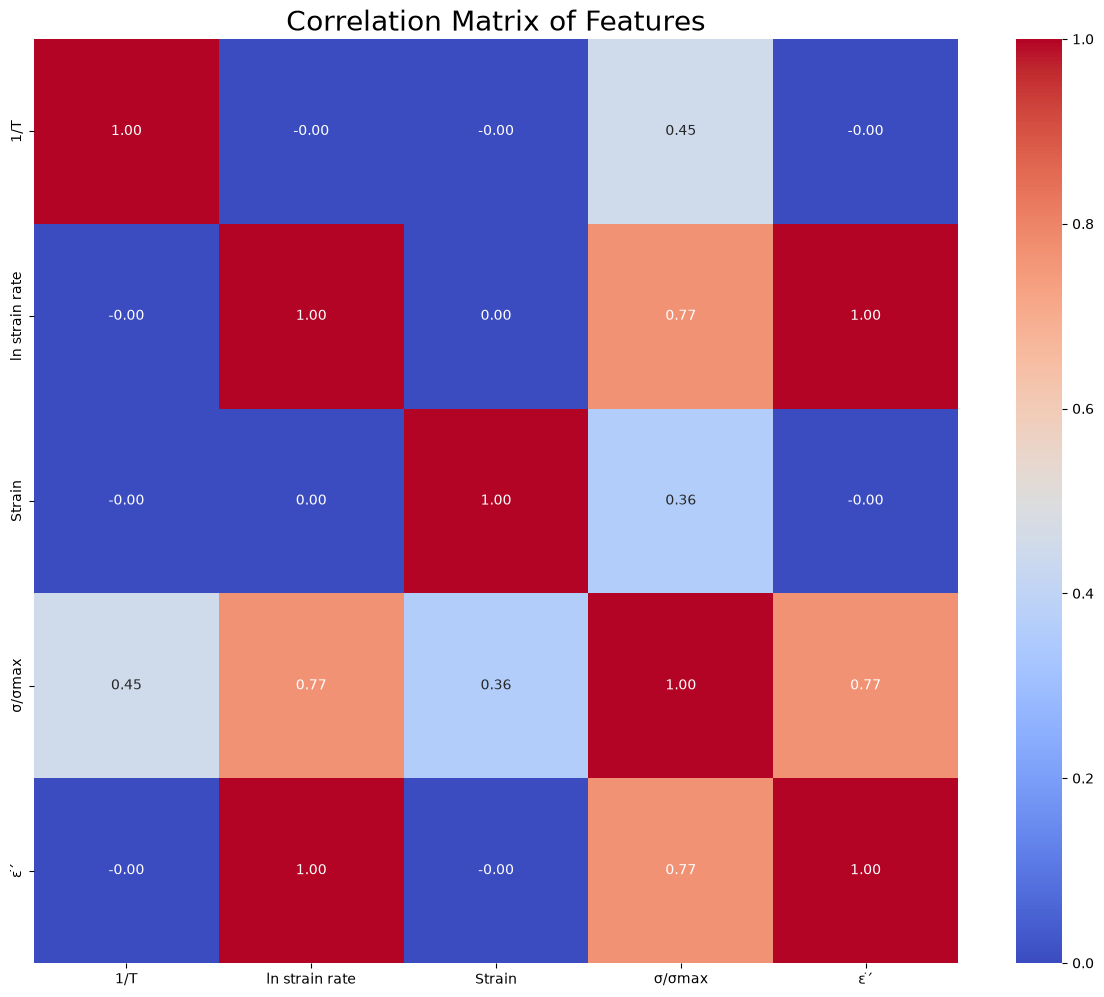

In [17]:
# Create a correlation heatmap
plt.figure(figsize=(15,12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt ='.2f', cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Features", fontsize=20)
plt.show()

## Correlation Heatmap Interpretation

This is the most definitive plot in the exploratory analysis because it summarizes the relationships between all variables in a single view.

### ln(Strain Rate) vs ε' = 1.00

This is a **perfect correlation**, which confirms that **ln(strain rate)** and **ε'** contain exactly the same information. In practical terms, these two columns are mathematically redundant.

Keeping both would introduce duplicate information into the ANN, which is unnecessary and can make the model less efficient. For this reason, **ε' should be removed**, while **ln(strain rate)** should be retained because it is already transformed into a scale that is more numerically stable for training.

---

### ln(Strain Rate) vs σ/σmax = 0.77

This is the **strongest linear relationship** in the dataset.

It shows that **strain rate is the most influential predictor** of normalized flow stress among the three input variables. The ANN is therefore expected to rely strongly on this feature when learning the material response.

---

### 1/T vs σ/σmax = 0.45

This indicates a **moderate positive correlation** between inverse temperature and normalized flow stress.

Temperature clearly affects the deformation behavior, but the relationship appears to be more **nonlinear** than that of strain rate. This explains why the correlation coefficient is lower. Although the linear correlation is moderate, the ANN should still be able to capture the more complex temperature effects that are not fully reflected in this value.

---

### Strain vs σ/σmax = 0.36

This is the **lowest linear correlation** among the three main inputs.

At first, this may seem unexpected because the earlier strain plot showed a clear increasing trend. However, the lower correlation is mainly due to the wide variation in stress caused by **temperature** and **strain rate** at the same strain values. This reduces the overall linear correlation coefficient.

Even so, strain remains an important predictor and should not be dismissed simply because its pairwise correlation is lower.

---

### Input-to-Input Correlations

The correlations between the three main input variables are all approximately zero:

- **1/T vs ln(Strain Rate) = -0.00**
- **1/T vs Strain = -0.00**
- **ln(Strain Rate) vs Strain = 0.00**

This means the three input features are essentially **independent of one another**.

From a modeling perspective, this is highly favorable because it means there is **no meaningful multicollinearity** among the retained predictors. Each input contributes a distinct signal, which gives the ANN a cleaner feature space to learn from.

## EDA Conclusions

The exploratory analysis confirms that the dataset is clean, structured, and physically consistent. It is well suited for ANN training, with no cleaning or imputation required.

### Dataset Structure

The dataset follows a complete **3 × 4 × 7 experimental grid** across three temperatures (**1/T**), four strain rates (**ln strain rate**), and seven strain levels (**0.1 to 0.7**), giving a total of **84 observations**. No missing combinations were identified.

### Feature Relationships

All three input features show clear and physically meaningful relationships with the target variable.

- **ln strain rate** is the strongest predictor (**r = 0.77**). Higher strain rates consistently produce higher flow stress across all conditions.
- **1/T** shows a moderate positive correlation (**r = 0.45**). As temperature decreases (**1/T increases**), flow stress increases, which agrees with hot deformation behavior.
- **Strain** shows the lowest linear correlation (**r = 0.36**), but the visual trend remains clear and monotonic. The lower correlation value is mainly caused by variation introduced by temperature and strain rate, not by noise.

### Feature Independence

Correlations between the three input variables are all effectively zero (**≈ 0.00**), confirming that there is no meaningful multicollinearity. Each feature contributes an independent signal to the model.

### Redundant Feature

The column **ε'** (raw strain rate) shows a perfect correlation of **1.00** with **ln strain rate**, confirming that both variables carry identical information. To avoid redundancy, **ε' will be removed before model training**.

### Target Distribution

The normalized flow stress (**σ/σmax**) ranges from approximately **0.17 to 1.00**, with most values concentrated between **0.5 and 0.9**. The lower and upper tails are relatively underrepresented, so predictions in these regions should be examined more carefully during model evaluation.

### Final Input and Output Definition

- **Inputs:** 1/T, ln strain rate, Strain
- **Output:** σ/σmax
- **Dropped:** ε'